### LangGraph Practice

In [1]:
for i in range(5):
    print("Hello World")

Hello World
Hello World
Hello World
Hello World
Hello World


In [2]:
!pip install -U langgraph langchain langchain-core langchain-community langchain-openai langchain-anthropic langchain-google-genai langsmith python-dotenv pydantic


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    msg: str


def hello_world_node(state: State) -> State:
    return {"msg": f"Hello {state['msg']} you are doing a Good Job !"}


builder = StateGraph(State)

builder.add_node("mid", hello_world_node)
builder.add_edge(START, "mid")
builder.add_edge("mid", END)

graph = builder.compile()

result = graph.invoke({"msg": "Naveed"})
print(result)

{'msg': 'Hello Naveed you are doing a Good Job !'}


In [4]:
from typing import TypedDict, List
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    final: str
    values: List[int]

def handler(state: State) -> State:
    state["final"] = f"This is returned Sum: {sum(state['values'])}"
    return state


graph = StateGraph(State)
graph.add_node("handler", handler)
graph.add_edge(START,"handler")
graph.add_edge("handler",END)

app = graph.compile()

print(app.invoke({"values": [1, 2, 3, 4, 5]}))

{'final': 'This is returned Sum: 15', 'values': [1, 2, 3, 4, 5]}


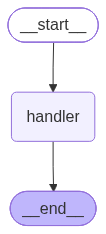

In [5]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
#Exercise 2

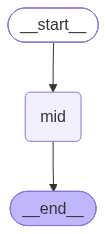

{'name': 'Naveed', 'final': 'Hi Naveed , the  answer is : 10', 'values': [1, 2, 3, 4], 'operator': '+'}


In [7]:
from langgraph.graph import StateGraph
from typing import List,TypedDict
import math
from IPython.display  import Image,display

class State(TypedDict):
    name : str
    final : str
    values : List[int]
    operator : str

def processsor(state: State)->State:
    if(state['operator'] == '+'):
        state['final'] = f"Hi {state['name']} , the  answer is : {sum(state['values'])}"
    else:
        state['final'] = f"Hi {state['name']} , the  answer is : {(math.prod(state['values']))}"

    return state

graph = StateGraph(State)
graph.add_node("mid" , processsor)
graph.set_entry_point("mid")
graph.set_finish_point("mid")
app = graph.compile()


display(Image(app.get_graph().draw_mermaid_png()))
res = app.invoke({"name": "Naveed" ,'operator':'+' ,'values':[1,2,3,4] })
print(res)


#### State Graph of multiple Nodes

In [8]:
from langgraph.graph import StateGraph
from typing import TypedDict

class State(TypedDict):
    name : str
    final:str

def First_Node(state:State)->State:
    state['final'] = f"Hi {state['name']} this is First Node Response"
    return state


def Second_Node(state:State)->State:
    state['final'] += f" , Wow {state['name']} this is Second Node Response"
    return state

graph = StateGraph(State)
graph.add_node("First_Node" , First_Node)
graph.add_node("Second_Node" , Second_Node)
graph.set_entry_point("First_Node")
graph.set_finish_point("Second_Node")
graph.add_edge("First_Node" , "Second_Node")

app = graph.compile()
res = app.invoke({"name" : "Naveed"})
print(res)




{'name': 'Naveed', 'final': 'Hi Naveed this is First Node Response , Wow Naveed this is Second Node Response'}


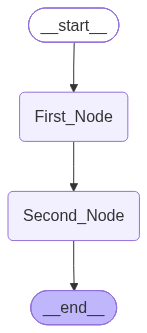

In [9]:
display(Image(app.get_graph().draw_mermaid_png()))

### Three Nodes Linear Graph

In [10]:
from langgraph.graph import StateGraph
from typing import TypedDict,List

class State(TypedDict):
    name : str
    final:str
    skills : List[str]
    Age:int

def First_Node(state:State)->State:
    state['final'] = f"Hi {state['name']} WELCOME to the TEAM  , "
    return state


def Second_Node(state:State)->State:
    state['final'] += f"You are {state['Age']}  years old  ,"
    return state


def Third_Node(state:State)->State:
    state['final'] += f" Your Skills are "
    state['final'] += ", ".join(state["skills"])
    
    return state

graph = StateGraph(State)
graph.add_node("First_Node" , First_Node)
graph.add_node("Second_Node" , Second_Node)
graph.add_node("Third_Node" , Third_Node)
graph.set_entry_point("First_Node")
graph.set_finish_point("Third_Node")
graph.add_edge("First_Node" , "Second_Node")
graph.add_edge("Second_Node","Third_Node")

app = graph.compile()
res = app.invoke({"name" : "Naveed" , "skills" : ["python" , "ai" , "ML"] , 'Age' : 20})
print(res)




{'name': 'Naveed', 'final': 'Hi Naveed WELCOME to the TEAM  , You are 20  years old  , Your Skills are python, ai, ML', 'skills': ['python', 'ai', 'ML'], 'Age': 20}


### Conditional Edges

In [11]:
from typing import TypedDict 
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    num1:int
    num2:int
    result:int
    operator:str


def Adder(state:State)->State:
    """This Function is to add Two numbers"""
    state['result'] = state['num1'] + state['num2']
    return state


def Subtracter(state:State)->State:
    """This Function is to Subtract Two numbers"""
    state['result'] = state['num1'] + state['num2']
    return state

def Multiplier(state:State)->State:
    """This Function is to Subtract Two numbers"""
    state['result'] = state['num1'] * state['num2']
    return state

def decision(state:State):
    if(state['operator'] == '+'):
        return "add_them"
    elif (state['operator'] == '-'):
        return "subtract_them"
    else:
        return "multiply_them"

In [12]:
graph = StateGraph(State)

graph.add_node("starter" , lambda x : x)
graph.add_edge(START,"starter")

graph.add_node('adder',Adder)
graph.add_node('subtract',Subtracter)
graph.add_node('multiplier',Multiplier)

graph.add_conditional_edges(
    "starter",
    decision,

    {
        "add_them" : "adder",
        "subtract_them" : "subtract",
        "multiply_them" : 'multiplier'
    }
)
graph.add_edge("adder",END)
graph.add_edge("subtract" , END)
graph.add_edge("multiplier" , END)

app = graph.compile()

input = State(num1=25 , num2=5, operator= "*")
print(app.invoke(input))

{'num1': 25, 'num2': 5, 'result': 125, 'operator': '*'}


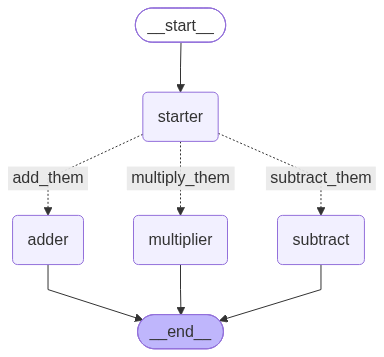

In [13]:
from IPython.display import display,Image

display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    num1:int
    num2:int
    num3:int
    num4:int
    final1:int
    final2:int
    op1:str
    op2:str

def adder1(state:State)->State:
    state['final1'] = state['num1'] + state['num2']
    return state

def adder2(state:State)->State:
    state['final2'] = state['num3'] + state['num4']
    return state

def subtract1(state:State)->State:
    state['final1'] = state['num1'] - state['num2']
    return state

def subtract2(state:State)->State:
    state['final2'] = state['num3'] - state['num4']
    return state

def decider1(state :State):
    if(state['op1'] == '+'):
        return 'add_them'
    elif(state['op1'] == '-'):
        return 'subtract_them'
    
def decider2(state :State):
    if(state['op2'] == '+'):
        return 'add_them'
    elif(state['op2'] == '-'):
        return 'subtract_them'


In [15]:
graph = StateGraph(State)

graph.add_node("router", lambda x : x)
graph.add_node("router2", lambda x : x)

graph.add_edge(START , "router")

graph.add_node("adder1" , adder1)
graph.add_node("subtract1" , subtract1)
graph.add_conditional_edges("router" ,decider1 ,{'add_them' : "adder1" ,'subtract_them' : 'subtract1' } )

graph.add_node("adder2" , adder2)
graph.add_node("subtract2" , subtract2)

graph.add_edge("adder1" ,"router2" )
graph.add_edge("subtract1" ,"router2" )

graph.add_conditional_edges("router2" ,decider2 ,{'add_them' : "adder2" ,'subtract_them' : 'subtract2' } )

graph.add_edge("adder2",END)
graph.add_edge("subtract2",END)

app = graph.compile()



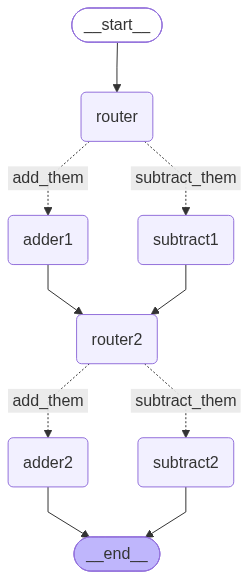

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
input2 = State(num1 = 5 , num2 = 10 , num3 = 15,num4 = 20 ,op1='+' , op2='+')
print(app.invoke(input2))

{'num1': 5, 'num2': 10, 'num3': 15, 'num4': 20, 'final1': 15, 'final2': 35, 'op1': '+', 'op2': '+'}


### Looping Graph

In [18]:
from typing import TypedDict,List
from langgraph.graph import StateGraph , START ,END
import random

class State(TypedDict):
    counter:int
    val :List[int]

def router(state:State)->State:
    if state['counter'] < 0 :
        state['counter'] = 0
    return state

def main_Node(state:State)->State:
    state['val'].append(random.randint(0,15))
    state["counter"] += 1
    return state

def decider(state:State):
    if(state['counter'] <= 5 ):
        return "loop"
    else:
        return "stop"

graph =StateGraph(State)
graph.add_node("router",router)
graph.add_edge(START,"router")
graph.add_node("main_node",main_Node)
graph.add_edge("router","main_node")
graph.add_conditional_edges("main_node",decider,{"loop" : "main_node"  , "stop" : END})
app = graph.compile()
print(app.invoke({"counter" :1 , "val" : []}))


{'counter': 6, 'val': [0, 2, 7, 1, 11]}


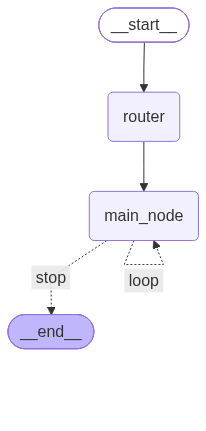

In [19]:
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
import random


class State(TypedDict):
    lower_bound: int
    upper_bound: int
    guess: int
    counter: int
    result: int


def starter(state: State):
    return {
        "lower_bound": 1,
        "upper_bound": 20,
        "counter": 7,
    }


def main(state: State):
    guess = random.randint(
        state["lower_bound"],
        state["upper_bound"]
    )

    remaining = state["counter"] - 1

    print("Remaining chances:", remaining)
    print(
        f"Current range: "
        f"{state['lower_bound']} to {state['upper_bound']}"
    )
    print("Computer guessed:", guess)

    return {
        "guess": guess,
        "counter": remaining,
    }


def decider(state: State) -> Literal["STOP", "UPDATE"]:
    if state["guess"] == state["result"]:
        print("YOU WON!")
        return "STOP"

    if state["counter"] < 1:
        print("OUT OF TURNS!")
        return "STOP"

    return "UPDATE"


def update_bounds(state: State):
    if state["guess"] > state["result"]:
        # -1 prevents guessing the same value again
        new_upper_bound = state["guess"] - 1

        print(
            f"Guess {state['guess']} is greater than "
            f"target {state['result']}"
        )
        print(f"Upper bound set to {new_upper_bound}")

        return {
            "upper_bound": new_upper_bound
        }

    # +1 prevents guessing the same value again
    new_lower_bound = state["guess"] + 1

    print(
        f"Guess {state['guess']} is lower than "
        f"target {state['result']}"
    )
    print(f"Lower bound set to {new_lower_bound}")

    return {
        "lower_bound": new_lower_bound
    }


graph = StateGraph(State)

graph.add_node("starter", starter)
graph.add_node("main", main)
graph.add_node("update_bounds", update_bounds)

graph.add_edge(START, "starter")
graph.add_edge("starter", "main")

graph.add_conditional_edges(
    "main",
    decider,
    {
        "STOP": END,
        "UPDATE": "update_bounds",
    }
)

graph.add_edge("update_bounds", "main")

app = graph.compile()

result = app.invoke({"result": 15})
print("Final state:", result)

Remaining chances: 6
Current range: 1 to 20
Computer guessed: 6
Guess 6 is lower than target 15
Lower bound set to 7
Remaining chances: 5
Current range: 7 to 20
Computer guessed: 12
Guess 12 is lower than target 15
Lower bound set to 13
Remaining chances: 4
Current range: 13 to 20
Computer guessed: 16
Guess 16 is greater than target 15
Upper bound set to 15
Remaining chances: 3
Current range: 13 to 15
Computer guessed: 14
Guess 14 is lower than target 15
Lower bound set to 15
Remaining chances: 2
Current range: 15 to 15
Computer guessed: 15
YOU WON!
Final state: {'lower_bound': 15, 'upper_bound': 15, 'guess': 15, 'counter': 2, 'result': 15}


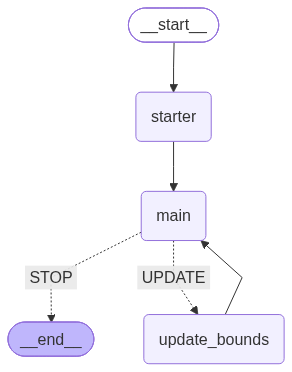

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

### Agents

In [22]:
!pip install -U langchain-google-genai


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
!pip install python-dotenv langchain langchain-google-genai langchain-community langchain-text-splitters langchain-ollama langchain-chroma requests beautifulsoup4 wikipedia duckduckgo-search

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/23.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/23.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.5 MB ? eta -:--:--
    --------------------------------------- 0.5/23.5 MB 558.9 kB/s eta 0:00:42
    --------------------------------------- 0.5/23.5 MB 558.9 kB/s eta 0:00:42
   - -------------------------------------- 0.8/23.5 MB 558.9 kB/s eta 0:00:41
   - -------------------------------------- 0.8/23.5 MB 558.9 kB/s eta 0:00:41
   -


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite", 
    temperature=0.7,
    max_retries=2
)
print(llm.invoke("What is 2 + 5"))


c:\Users\Naveed Hassan\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


content=[{'type': 'text', 'text': '2 + 5 = 7', 'extras': {'signature': 'El4KXAERTTIPAcYVuz+f1FYpsi2lbeqp8GYaSV3LOSmMMY4eUOe/q+GSnWKkyvr0mkZpG8c4nx0Pjns5Oif56YYIt6W3vzFdTeyY7vn3KxSPhCJJCTfuyupWwOCQY51Q'}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a0041a-a029-7051-8131-c0705ed57aeb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8, 'output_tokens': 7, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}}


In [3]:
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage
from IPython.display import display,Image
class State(TypedDict):
    messages:List[HumanMessage]
    response:str

def starter(state:State)->State:
    val = input("Enter the Input to ask AI : ")
    state["messages"] = [HumanMessage(content=val)]
    return state

def searcher(state:State)->State:
    res = llm.invoke(state["messages"])
    state["response"] = res
    return state

graph = StateGraph(State)
graph.add_node("starter",starter)
graph.add_node("caller",searcher)
graph.add_edge(START,"starter")
graph.add_edge("starter" , "caller")
graph.add_edge("caller", END)
app = graph.compile()


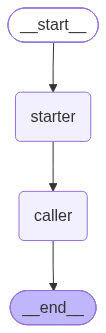

In [27]:
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
res = app.invoke({})
print(res)

c:\Users\Naveed Hassan\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'messages': [HumanMessage(content='What is 2 + 5 = ', additional_kwargs={}, response_metadata={})], 'response': AIMessage(content=[{'type': 'text', 'text': '2 + 5 = 7', 'extras': {'signature': 'El4KXAERTTIPz+xIb6n95ipiLNkp5KcqLQu0V3IPZHBP0t6gDhUgarDZGgqJ+wjduD/i1ifAKNT61lGwuM1ngbTVKdZQ7/Awsd0hA3UnnUejrFrxmX1hb3Wb92mo6nvo'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0041b-0add-71a2-989a-77bec8c275dd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 7, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}})}


## Building Ai Agent With Memory of Current Execution

In [14]:
from typing import TypedDict ,List ,Union
from langgraph.graph import StateGraph , START,END
from langchain_core.messages import HumanMessage,AIMessage

class State(TypedDict):
    messages : List[Union[HumanMessage , AIMessage]]

def Main(state:State)->State:
    res = llm.invoke(state['messages'])
    print(f"AI Response is : {res.content}")
    state['messages'].append(AIMessage(res.content))
    print("Current State is : " , state["messages"])
    return state

graph = StateGraph(State)
graph.add_node("main" , Main)
graph.add_edge(START,"main")
graph.add_edge("main",END)
app = graph.compile()

temp = []
while True:
    inpu = input("Enter : ")
    if(inpu == "END"):
        break

    temp.append(HumanMessage(inpu))
    print("User input : " ,inpu)
    app.invoke({"messages" : temp})


with open("record.txt", "w") as file:
    file.write("Your Conversation Log:\n")

    for message in temp:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content[0]["text"]}\n\n")

    file.write("End of Conversation")

print("Conversation saved to logging.txt")
    



User input :  Hy


c:\Users\Naveed Hassan\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


AI Response is : [{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIP6P73Is3hmjon21MB+U/OpsvLf6KWGl2J+Y/EiJXjnYYDhxU6oDt7A6WOJOl+gYioOg1fy8CB48C9pkBdsojPd6uXmFmFkHH8iXRYn+RNklbKaGBhoFnz'}}]
Current State is :  [HumanMessage(content='Hy', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIP6P73Is3hmjon21MB+U/OpsvLf6KWGl2J+Y/EiJXjnYYDhxU6oDt7A6WOJOl+gYioOg1fy8CB48C9pkBdsojPd6uXmFmFkHH8iXRYn+RNklbKaGBhoFnz'}}], additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
Conversation saved to logging.txt


## React Agent , Reasoning and Acting Agent

In [ ]:
# Creating Agent
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite", 
    temperature=0.5,
)

In [5]:
from typing import TypedDict, Annotated, Sequence
#Annotated is for applying kind of Constraints,Stream Append values ,You can also use List in Place of This 
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import END, StateGraph, START
#Add_message auto append Messages instead of overriding Whole
from langgraph.graph.message import add_messages
#ToolNode Executes the Last Selected Tool Choosed By LLM and add its reponse in meessages field in term of ToolMessage
from langgraph.prebuilt import ToolNode


class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def add(a: int, b: int) -> int:
    """This tool will add two numbers."""
    return a + b


tools = [add]
llm_with_tools = llm.bind_tools(tools)


def main_node(state: State) -> State:
    res = llm_with_tools.invoke(
        [
            SystemMessage(
                content="You are a teacher explaining things to a naive student."
            )
        ]
        + list(state["messages"])
    )

    return {
        "messages": [res]
    }


tool_node = ToolNode(tools)


def decider(state: State):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "continue"

    return "end"


graph = StateGraph(State)

graph.add_node("main", main_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "main")

graph.add_conditional_edges(
    "main",
    decider,
    {
        "end": END,
        "continue": "tool_node",
    }
)

graph.add_edge("tool_node", "main")

app = graph.compile()


def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]

        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {
    "messages": [
        ("user", "Add 40 + 12")
    ]
}

print_stream(
    app.stream(
        inputs,
        stream_mode="values"
    )
)

================================ Human Message =================================

Add 40 + 12


c:\Users\Naveed Hassan\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[]
Tool Calls:
  add (call_3453502)
 Call ID: call_3453502
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52


c:\Users\Naveed Hassan\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================== Ai Message ==================================

[{'type': 'text', 'text': 'When we add 40 and 12 together, we get **52**! \n\nHere is how you can think about it:\n1. First, add the numbers in the ones place: 0 + 2 = 2.\n2. Next, add the numbers in the tens place: 4 + 1 = 5.\n3. Put them together, and you get 52!', 'extras': {'signature': 'El4KXAERTTIP7O5ZbqilRxKvpRAPDpFsV/MUTP/8iJSTIg7p9ftsVxwUL9GwDHwH6P96k7YVhf+ZsTX1L1DiilTOD3itChS1LW8FW9zb+Bq1QLrB+GV85wVtAu8VCTdY'}}]
